# Convolutional Autoencoder Training

## Objective

The goal of this notebook is to train a Convolutional Autoencoder for 2× image super-resolution on the retro gaming dataset.

The model receives a bicubic-upscaled low-resolution image as input and learns to reconstruct the corresponding high-resolution image.

In [3]:
from pathlib import Path
import sys

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
import torch
import torch.nn as nn

from src.models.autoencoder import ConvAutoencoder

from src.dataloader import (
    get_train_loader,
    get_validation_loader
)

from src.train import train_one_epoch
from src.evaluate import evaluate

from src.config import LEARNING_RATE, NUM_EPOCHS

## Device

Select the device used for training.

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## DataLoader

In [6]:
train_loader = get_train_loader()
valid_loader = get_validation_loader()

## Model

In [7]:
model = ConvAutoencoder().to(device)

print(model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (bottleneck): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddi

## Loss Function

In [8]:
criterion = nn.MSELoss()

## Optimizer

In [9]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [10]:
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=50,
    gamma=0.5
)

## Training

In [11]:
from src.checkpoint import save_model

TRAIN_EPOCHS = 200

loss_history = []
best_psnr = 0.0

patience = 20
epochs_without_improvement = 0

train_loss_history = []
valid_loss_history = []
valid_psnr_history = []

for epoch in range(TRAIN_EPOCHS):

    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_psnr = evaluate(
        model=model,
        dataloader=valid_loader,
        criterion=criterion,
        device=device
    )

    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    valid_psnr_history.append(valid_psnr)

    print(
        f"Epoch {epoch+1}/{TRAIN_EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Valid Loss: {valid_loss:.6f} | "
        f"PSNR: {valid_psnr:.2f} dB | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    if valid_psnr > best_psnr:

        best_psnr = valid_psnr

        epochs_without_improvement = 0

        save_model(
            model,
            "../results/checkpoints/autoencoder_best.pth"
        )

        print("Best model saved!")

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print("\nEarly stopping activated!")

        break

    scheduler.step()

Epoch 1/200 | Train Loss: 0.058321 | Valid Loss: 0.016549 | PSNR: 17.88 dB | LR: 0.000100
Best model saved!
Epoch 2/200 | Train Loss: 0.017327 | Valid Loss: 0.016162 | PSNR: 18.13 dB | LR: 0.000100
Best model saved!
Epoch 3/200 | Train Loss: 0.014470 | Valid Loss: 0.015440 | PSNR: 18.40 dB | LR: 0.000100
Best model saved!
Epoch 4/200 | Train Loss: 0.011605 | Valid Loss: 0.011902 | PSNR: 19.43 dB | LR: 0.000100
Best model saved!
Epoch 5/200 | Train Loss: 0.009448 | Valid Loss: 0.008565 | PSNR: 20.96 dB | LR: 0.000100
Best model saved!
Epoch 6/200 | Train Loss: 0.006748 | Valid Loss: 0.005521 | PSNR: 22.70 dB | LR: 0.000100
Best model saved!
Epoch 7/200 | Train Loss: 0.005484 | Valid Loss: 0.005264 | PSNR: 22.85 dB | LR: 0.000100
Best model saved!
Epoch 8/200 | Train Loss: 0.005685 | Valid Loss: 0.006097 | PSNR: 22.36 dB | LR: 0.000100
Epoch 9/200 | Train Loss: 0.004650 | Valid Loss: 0.004771 | PSNR: 23.47 dB | LR: 0.000100
Best model saved!
Epoch 10/200 | Train Loss: 0.004677 | Valid Lo

In [12]:
from src.checkpoint import save_checkpoint

save_checkpoint(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    epoch=68,
    best_psnr=best_psnr,
    filepath="../results/checkpoints/autoencoder_training_checkpoint.pth"
)

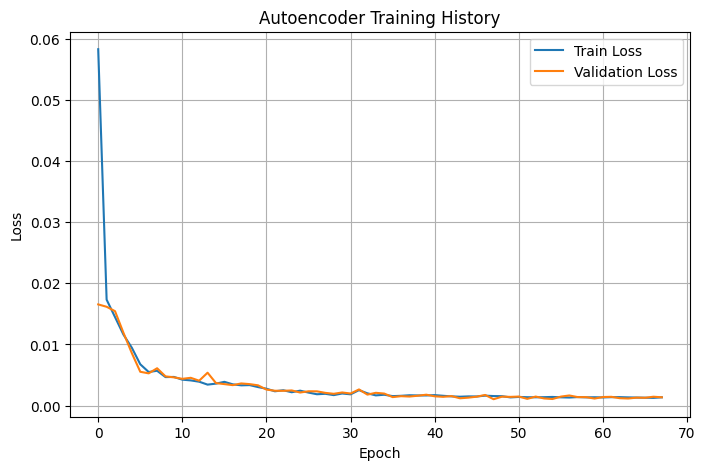

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training History")

plt.legend()

plt.grid(True)

plt.show()

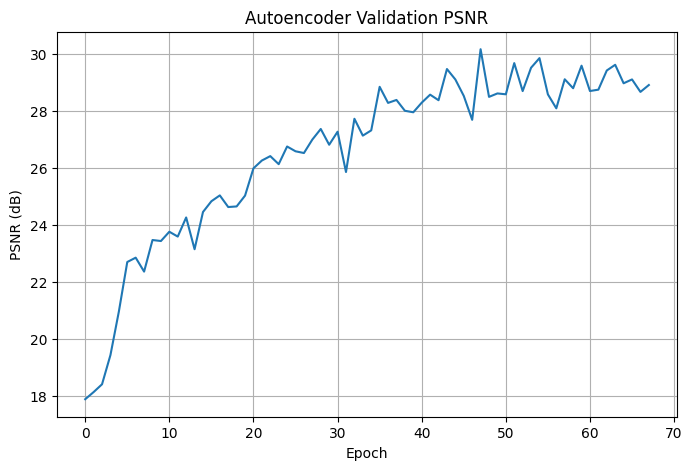

In [14]:
plt.figure(figsize=(8,5))

plt.plot(valid_psnr_history)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Autoencoder Validation PSNR")

plt.grid(True)

plt.show()

In [15]:
import json

history = {
    "train_loss": train_loss_history,
    "valid_loss": valid_loss_history,
    "valid_psnr": valid_psnr_history
}

with open("../results/metrics/autoencoder_training_history.json", "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved.")

Training history saved.


In [16]:
from src.checkpoint import save_model

save_model(
    model,
    "../results/checkpoints/autoencoder_x2_200epochs.pth"
)

print("Final model saved.")

Final model saved.


In [17]:
from src.checkpoint import load_model

model = ConvAutoencoder().to(device)

model = load_model(
    model,
    "../results/checkpoints/autoencoder_x2_200epochs.pth",
    device
)

print("Autoencoder loaded successfully.")

Autoencoder loaded successfully.


c:\Users\aless\Documents\RetroSR-CNN\src\checkpoint.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filepath, map_location=device)
